In [111]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

## Tensor Question 1

In [112]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, tensor in [("a", a), ("b", b), ("c", c)]:
    print(f"{name}:")
    print(tensor)
    print(f"shape: {tensor.shape}")
    print(f"dtype: {tensor.dtype}")
    print(f"device: {tensor.device}")
    print()

a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

c:
tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu



These tensors are currently on the CPU because I did not move them to the GPU yet. If I were running a training loop on the GPU, it would matter that the model weights and input tensors are on the same device because PyTorch cannot do calculations between tensors stored on different devices. Keeping both the model and data on the GPU also helps training run faster.

## Tensor Question 2

In [113]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("Square root:")
print(torch.sqrt(x))

print("\nSum:")
print(x.sum())

print("\nMean:")
print(x.mean())

print("\nArgmax:")
print(x.argmax())

Square root:
tensor([1., 2., 3., 4., 5.])

Sum:
tensor(55.)

Mean:
tensor(11.)

Argmax:
tensor(4)


In a classifier that outputs scores for 1,000 classes, `.argmax()` gives the index of the class with the highest score. That index is used to look up the predicted class label.

## Tensor Question 3

In [114]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


PyTorch requires `.cpu()` before calling `.numpy()` because NumPy arrays live in regular CPU memory, not GPU memory. If a tensor is on the GPU, it must be copied back to the CPU before NumPy can work with it.

## Tensor Question 4

In [115]:
t = torch.arange(24).float()

t_4_6 = t.reshape(4, 6)
print("Shape after reshape to (4, 6):")
print(t_4_6.shape)

t_2_3_4 = t.reshape(2, 3, 4)
print("\nShape after reshape to (2, 3, 4):")
print(t_2_3_4.shape)

t_batch = t_4_6.unsqueeze(0)
print("\nShape after adding new dimension at position 0:")
print(t_batch.shape)

Shape after reshape to (4, 6):
torch.Size([4, 6])

Shape after reshape to (2, 3, 4):
torch.Size([2, 3, 4])

Shape after adding new dimension at position 0:
torch.Size([1, 4, 6])


The operation that adds a batch dimension is `.unsqueeze(0)`. This matters because a single image may have shape `(channels, height, width)`, but neural networks expect a batch shape of `(batch_size, channels, height, width)`. When processing one image, `.unsqueeze(0)` creates a batch size of 1.

## Tensor Question 5

In [116]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np_a @ np_b
torch_result = t_a @ t_b

print("NumPy result:")
print(np_result)

print("\nPyTorch result:")
print(torch_result)

print("\nOutputs match:")
print(np.allclose(np_result, torch_result.numpy()))

NumPy result:
[[19. 22.]
 [43. 50.]]

PyTorch result:
tensor([[19., 22.],
        [43., 50.]])

Outputs match:
True


Matrix multiplication is one of the main operations inside a neural network layer. At a high level, the input data is multiplied by learned weights, then a bias and activation function are applied to produce the next layer’s output.

## Pretrained Models

## Model Question 1

In [117]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,689,512
Trainable parameters: 11,689,512


ResNet18 has roughly 11 million parameters, which would require a huge dataset and a lot of compute to train from scratch. Starting with pretrained weights is valuable because the model has already learned useful image patterns, saving time, money, and training resources.

## Model Question 2

In [118]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

The final layer in ResNet18 is named `fc`, which stands for fully connected layer. Its output size is 1000 because the pretrained ImageNet model predicts 1,000 possible categories.

The blocks named `layer1` through `layer4` are the deeper feature extraction parts of the network. A network is "deep" because it has many layers stacked together, allowing it to learn simple features like edges early on and more complex features like objects or scenes in later layers.

## Model Question 3

In [119]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


`model.to(device)` moves the model to the GPU if one is available, or keeps it on the CPU if not. This needs to match the device of the input tensors because PyTorch operations require the model and inputs to be on the same device.

`model.eval()` switches the model into evaluation mode. This changes the behavior of layers like dropout and batch normalization, which behave differently during training versus inference.

## Model Question 4

In [120]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


The resize and crop steps make the input image the correct size for ResNet18. `ToTensor()` converts the PIL image into a PyTorch tensor and scales pixel values from 0-255 into a smaller numeric range. Normalization adjusts the image using the same ImageNet mean and standard deviation that were used when the model was originally trained. This matters because the model expects new images to be processed in the same way as its training images.

## Running Inference

## Setup Image Helper

In [ ]:
from pathlib import Path
from PIL import Image
import random

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")

LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):

    label_dir = DATA_DIR / label

    print("Checking folder:", label_dir)

    if not label_dir.exists():
        raise FileNotFoundError(f"Folder does not exist: {label_dir}")

    paths = (
        list(label_dir.glob("*.jpg")) +
        list(label_dir.glob("*.jpeg")) +
        list(label_dir.glob("*.png"))
    )

    print("Label:", label)
    print("Images found:", len(paths))

    if len(paths) == 0:
        raise FileNotFoundError(f"No images found for {label}")

    img_path = random.choice(paths)

    return Image.open(img_path).convert("RGB"), img_path.name

## ImageNet Classes

In [122]:
imagenet_classes = weights.meta["categories"]

print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Inference Question 1

In [123]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, 5)

    results = []

    for prob, index in zip(top_probs, top_indices):
        class_name = class_labels[index.item()]
        results.append((class_name, prob.item()))

    return results

The top prediction may not literally say "mountain" because ResNet18 was trained on ImageNet’s 1,000 categories, not the Intel scene labels. Labels like `alp`, `valley`, `lakeside`, or similar outdoor categories still make sense because they describe visual features that could appear in a mountain scene.

In [124]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")

for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain
Label: mountain
Images found: 525

Top-5 predictions for '22504.jpg':
  alp                             0.6402
  volcano                         0.1667
  valley                          0.1084
  mountain tent                   0.0176
  promontory                      0.0169


### Inference Question 2

In [125]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]

    print(f"\n[{label}]  {img_name}")

    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/buildings
Label: buildings
Images found: 437

[buildings]  22534.jpg
  cab                             0.1014
  traffic light                   0.1010
  bell cote                       0.0862
Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest
Label: forest
Images found: 474

[forest]  21735.jpg
  lakeside                        0.1540
  worm fence                      0.1273
  mountain tent                   0.0553
Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/glacier
Label: glacier
Images found: 553

[glacier]  23541.jpg
  valley                          0.2068
  lakeside                        0.0998
  alp                             0.0687
Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain
Label: mountain
Images found: 525

[mountain] 

The model usually seems most confident when the scene contains objects or patterns that closely match ImageNet classes, such as streets, buildings, forests, or mountains. It may be less confident on broader scene categories like sea or glacier because ImageNet labels are object-focused and do not always match the exact Intel scene categories.

### Inference Question 3

In [126]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest
Label: forest
Images found: 474
Logit  range: min=-5.02, max=7.97
Prob   range: min=0.000000, max=0.1728
Probs sum to: 1.000000
Top prediction: thatch  (0.1728)


Neural networks output logits internally because logits are raw scores that are easier and more stable to use during training with loss functions like cross-entropy. In a production pipeline that filters low-confidence predictions, I would use probabilities because they are easier to interpret and compare against a confidence threshold.

### Inference Question 4

Checking folder: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain
Label: mountain
Images found: 525


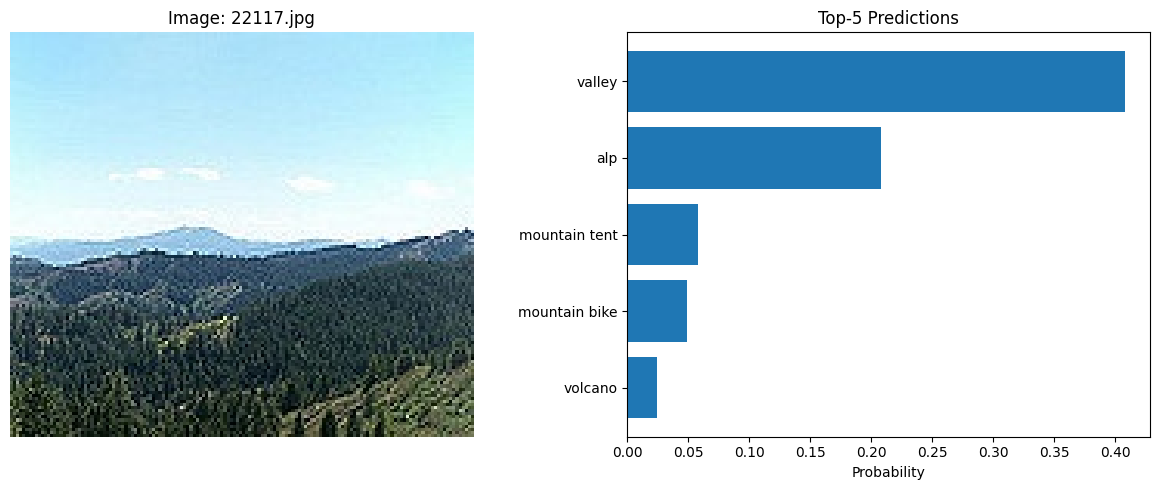

Saved visualization to outputs/warmup_inference_viz.png


In [127]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

class_names = [item[0] for item in preds]
probabilities = [item[1] for item in preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

axes[1].barh(class_names, probabilities)
axes[1].set_xlabel("Probability")
axes[1].set_title("Top-5 Predictions")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()

print("Saved visualization to outputs/warmup_inference_viz.png")

For a dashboard used by a non-technical team member, I would show the image, the top prediction, the confidence score, and the top alternative predictions in a simple chart. I might use a top-1 probability threshold around 0.70 or 0.80 before treating a prediction as confident enough to act on, depending on how risky the decision is.